In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
# ✅ LOAD DATA
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
# Reduce size (avoid crash)
x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

# Resize
x_train = np.array([cv2.resize(img, (224,224)) for img in x_train])
x_test = np.array([cv2.resize(img, (224,224)) for img in x_test])

# Preprocess
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

In [ ]:
# One-hot
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# ✅ MODEL
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x) # Add a Dropout layer for regularization
output = Dense(10, activation='softmax')(x)

In [ ]:
model = Model(inputs=base_model.input, outputs=output)

# Unfreeze some layers of the base model for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# ✅ COMPILE (recompile after unfreezing layers with a lower learning rate)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ TRAIN (train for more epochs for fine-tuning)
history = model.fit(x_train, y_train, epochs=10, batch_size=16, validation_data=(x_test, y_test))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 104ms/step - accuracy: 0.2974 - loss: 2.0374 - val_accuracy: 0.5090 - val_loss: 1.5385
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5602 - loss: 1.3868 - val_accuracy: 0.6950 - val_loss: 1.0125
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6664 - loss: 1.0573 - val_accuracy: 0.7360 - val_loss: 0.7956
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7202 - loss: 0.8738 - val_accuracy: 0.7620 - val_loss: 0.7011
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7542 - loss: 0.7719 - val_accuracy: 0.7810 - val_loss: 0.6351
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7722 - loss: 0.7112 - val_accuracy: 0.8010 - val_loss: 0.5935
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7948 - loss: 0.6408 - val_accuracy: 0.8140 - val_loss: 0.5600
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8182 - loss: 0.5870 - val_a

In [ ]:
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

📤 Upload an image


Saving Charming.jpg to Charming.jpg


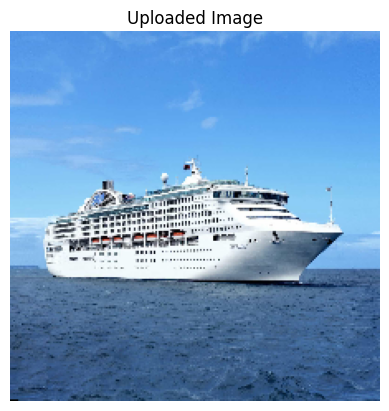

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
✅ Predicted Class: ship


In [ ]:
from google.colab import files

print("📤 Upload an image")
uploaded = files.upload()

for fn in uploaded.keys():
    img = cv2.imread(fn)
    img = cv2.resize(img, (224,224))

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Uploaded Image")
    plt.axis('off')
    plt.show()

    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    print("✅ Predicted Class:", class_names[class_index])